In [2]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
import os

print(os.listdir('/content/drive/MyDrive'))

['projeto_yolo', 'Projeto Fase 6', 'Colab Notebooks']


In [ ]:
base = '/content/drive/MyDrive/Projeto Fase 6'

print(os.path.exists(base))
print(os.listdir(base))

True
['Treino', 'Teste', 'Resultados', 'Validacao']


In [ ]:
train_images = f'{base}/Treino/images'
train_labels = f'{base}/Treino/labels'
val_images = f'{base}/Validacao/images'
val_labels = f'{base}/Validacao/labels'
test_images = f'{base}/Teste/images'

print("Treino imagens:", len(os.listdir(train_images)), os.listdir(train_images)[:5])
print("Treino labels:", len(os.listdir(train_labels)), os.listdir(train_labels)[:5])
print("Validacao imagens:", len(os.listdir(val_images)), os.listdir(val_images)[:5])
print("Validacao labels:", len(os.listdir(val_labels)), os.listdir(val_labels)[:5])
print("Teste imagens:", len(os.listdir(test_images)), os.listdir(test_images)[:5])

Treino imagens: 64 ['Treino1.jpeg', 'Treino2.jpeg', 'Treino3.jpeg', 'Treino4.jpeg', 'Treino5.jpeg']
Treino labels: 61 ['Treino55.txt', 'Treino11.txt', 'Treino20.txt', 'Treino1.txt', 'Treino27.txt']
Validacao imagens: 8 ['Valida1.jpeg', 'Valida2.jpeg', 'Valida3.jpeg', 'Valida4.jpeg', 'Valida5.jpeg']
Validacao labels: 8 ['Valida1.txt', 'Valida3.txt', 'Valida2.txt', 'Valida4.txt', 'Valida8.txt']
Teste imagens: 8 ['Teste1.jpeg', 'Teste2.jpeg', 'Teste3.jpeg', 'Teste4.jpeg', 'Teste5.jpeg']


In [ ]:
import os

imgs_train = sorted([os.path.splitext(f)[0] for f in os.listdir(train_images) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
lbls_train = sorted([os.path.splitext(f)[0] for f in os.listdir(train_labels) if f.lower().endswith('.txt')])

imgs_val = sorted([os.path.splitext(f)[0] for f in os.listdir(val_images) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
lbls_val = sorted([os.path.splitext(f)[0] for f in os.listdir(val_labels) if f.lower().endswith('.txt')])

print("Qtd imagens treino:", len(imgs_train))
print("Qtd labels treino:", len(lbls_train))
print("Imagens treino sem label:", [img for img in imgs_train if img not in lbls_train][:10])

print("Qtd imagens validacao:", len(imgs_val))
print("Qtd labels validacao:", len(lbls_val))
print("Imagens validacao sem label:", [img for img in imgs_val if img not in lbls_val][:10])

Qtd imagens treino: 64
Qtd labels treino: 61
Imagens treino sem label: ['Treino15', 'Treino16', 'Treino18']
Qtd imagens validacao: 8
Qtd labels validacao: 8
Imagens validacao sem label: []


In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 33.3 MB/s eta 0:00:00


In [ ]:
import os
os.kill(os.getpid(), 9)

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
data_yaml = """
train: /content/drive/MyDrive/Projeto Fase 6/Treino/images
val: /content/drive/MyDrive/Projeto Fase 6/Validacao/images
test: /content/drive/MyDrive/Projeto Fase 6/Teste/images

names:
  0: Lapis
  1: Colher
"""

with open('/content/data.yaml', 'w') as f:
    f.write(data_yaml)

print("data.yaml criado com sucesso")

data.yaml criado com sucesso


In [ ]:
with open('/content/data.yaml', 'r') as f:
    print(f.read())


train: /content/drive/MyDrive/Projeto Fase 6/Treino/images
val: /content/drive/MyDrive/Projeto Fase 6/Validacao/images
test: /content/drive/MyDrive/Projeto Fase 6/Teste/images

names:
  0: Lapis
  1: Colher



In [ ]:
from ultralytics import YOLO

model = YOLO('yolov8n.pt')

model.train(
    data='/content/data.yaml',
    epochs=30,
    imgsz=640,
    project='/content/drive/MyDrive/Projeto Fase 6/Resultados',
    name='exp_30'
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, i

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7baaf0185d30>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04804

In [ ]:
from ultralytics import YOLO

model = YOLO('yolov8n.pt')

model.train(
    data='/content/data.yaml',
    epochs=60,
    imgsz=640,
    project='/content/drive/MyDrive/Projeto Fase 6/Resultados',
    name='exp_60'
)

Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=60, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=exp_60-2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspec

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7baa30246d80>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04804

In [ ]:
from ultralytics import YOLO

model = YOLO('/content/drive/MyDrive/Projeto Fase 6/Resultados/exp_60/weights/best.pt')

model.predict(
    source='/content/drive/MyDrive/Projeto Fase 6/Teste/images',
    save=True,
    project='/content/drive/MyDrive/Projeto Fase 6/Resultados',
    name='predicoes_teste'
)


image 1/8 /content/drive/MyDrive/Projeto Fase 6/Teste/images/Teste1.jpeg: 640x480 1 Lapis, 42.1ms
image 2/8 /content/drive/MyDrive/Projeto Fase 6/Teste/images/Teste2.jpeg: 640x480 1 Lapis, 1 Colher, 6.3ms
image 3/8 /content/drive/MyDrive/Projeto Fase 6/Teste/images/Teste3.jpeg: 640x480 4 Lapiss, 2 Colhers, 6.1ms
image 4/8 /content/drive/MyDrive/Projeto Fase 6/Teste/images/Teste4.jpeg: 640x480 2 Lapiss, 1 Colher, 6.1ms
image 5/8 /content/drive/MyDrive/Projeto Fase 6/Teste/images/Teste5.jpeg: 640x480 1 Colher, 8.1ms
image 6/8 /content/drive/MyDrive/Projeto Fase 6/Teste/images/Teste6.jpeg: 640x480 (no detections), 8.2ms
image 7/8 /content/drive/MyDrive/Projeto Fase 6/Teste/images/Teste7.jpeg: 640x480 2 Lapiss, 12.7ms
image 8/8 /content/drive/MyDrive/Projeto Fase 6/Teste/images/Teste8.jpeg: 640x480 1 Lapis, 1 Colher, 6.2ms
Speed: 2.9ms preprocess, 12.0ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 480)
Results saved to /content/drive/MyDrive/Projeto Fase 6/Resultados/predi

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'Lapis', 1: 'Colher'}
 obb: None
 orig_img: array([[[ 61,  61,  55],
         [ 62,  62,  56],
         [ 63,  62,  58],
         ...,
         [171, 173, 173],
         [171, 173, 173],
         [171, 173, 173]],
 
        [[ 61,  61,  55],
         [ 63,  63,  57],
         [ 64,  63,  59],
         ...,
         [170, 172, 172],
         [170, 172, 172],
         [170, 172, 172]],
 
        [[ 62,  62,  56],
         [ 64,  64,  58],
         [ 65,  64,  60],
         ...,
         [169, 171, 171],
         [169, 171, 171],
         [168, 170, 170]],
 
        ...,
 
        [[134, 139, 142],
         [130, 135, 138],
         [126, 131, 134],
         ...,
         [166, 166, 166],
         [166, 166, 166],
         [166, 166, 166]],
 
        [[133, 138, 141],
         [129, 134, 137],
         [125, 130, 133],
         ...,
      

In [ ]:
import os

In [ ]:
print(os.listdir('/content/drive/MyDrive/Projeto Fase 6/Resultados'))

['exp_30', 'exp_30-2', 'exp_60', 'predicoes_teste', 'exp_30-3', 'exp_60-2', 'predicoes_teste-2']


FileNotFoundError: No such file or directory: '/content/drive/MyDrive/Projeto Fase 6/Resultados/exp_30/results.png'

FileNotFoundError: No such file or directory: '/content/drive/MyDrive/Projeto Fase 6/Resultados/exp_30/results.png'

<IPython.core.display.Image object>

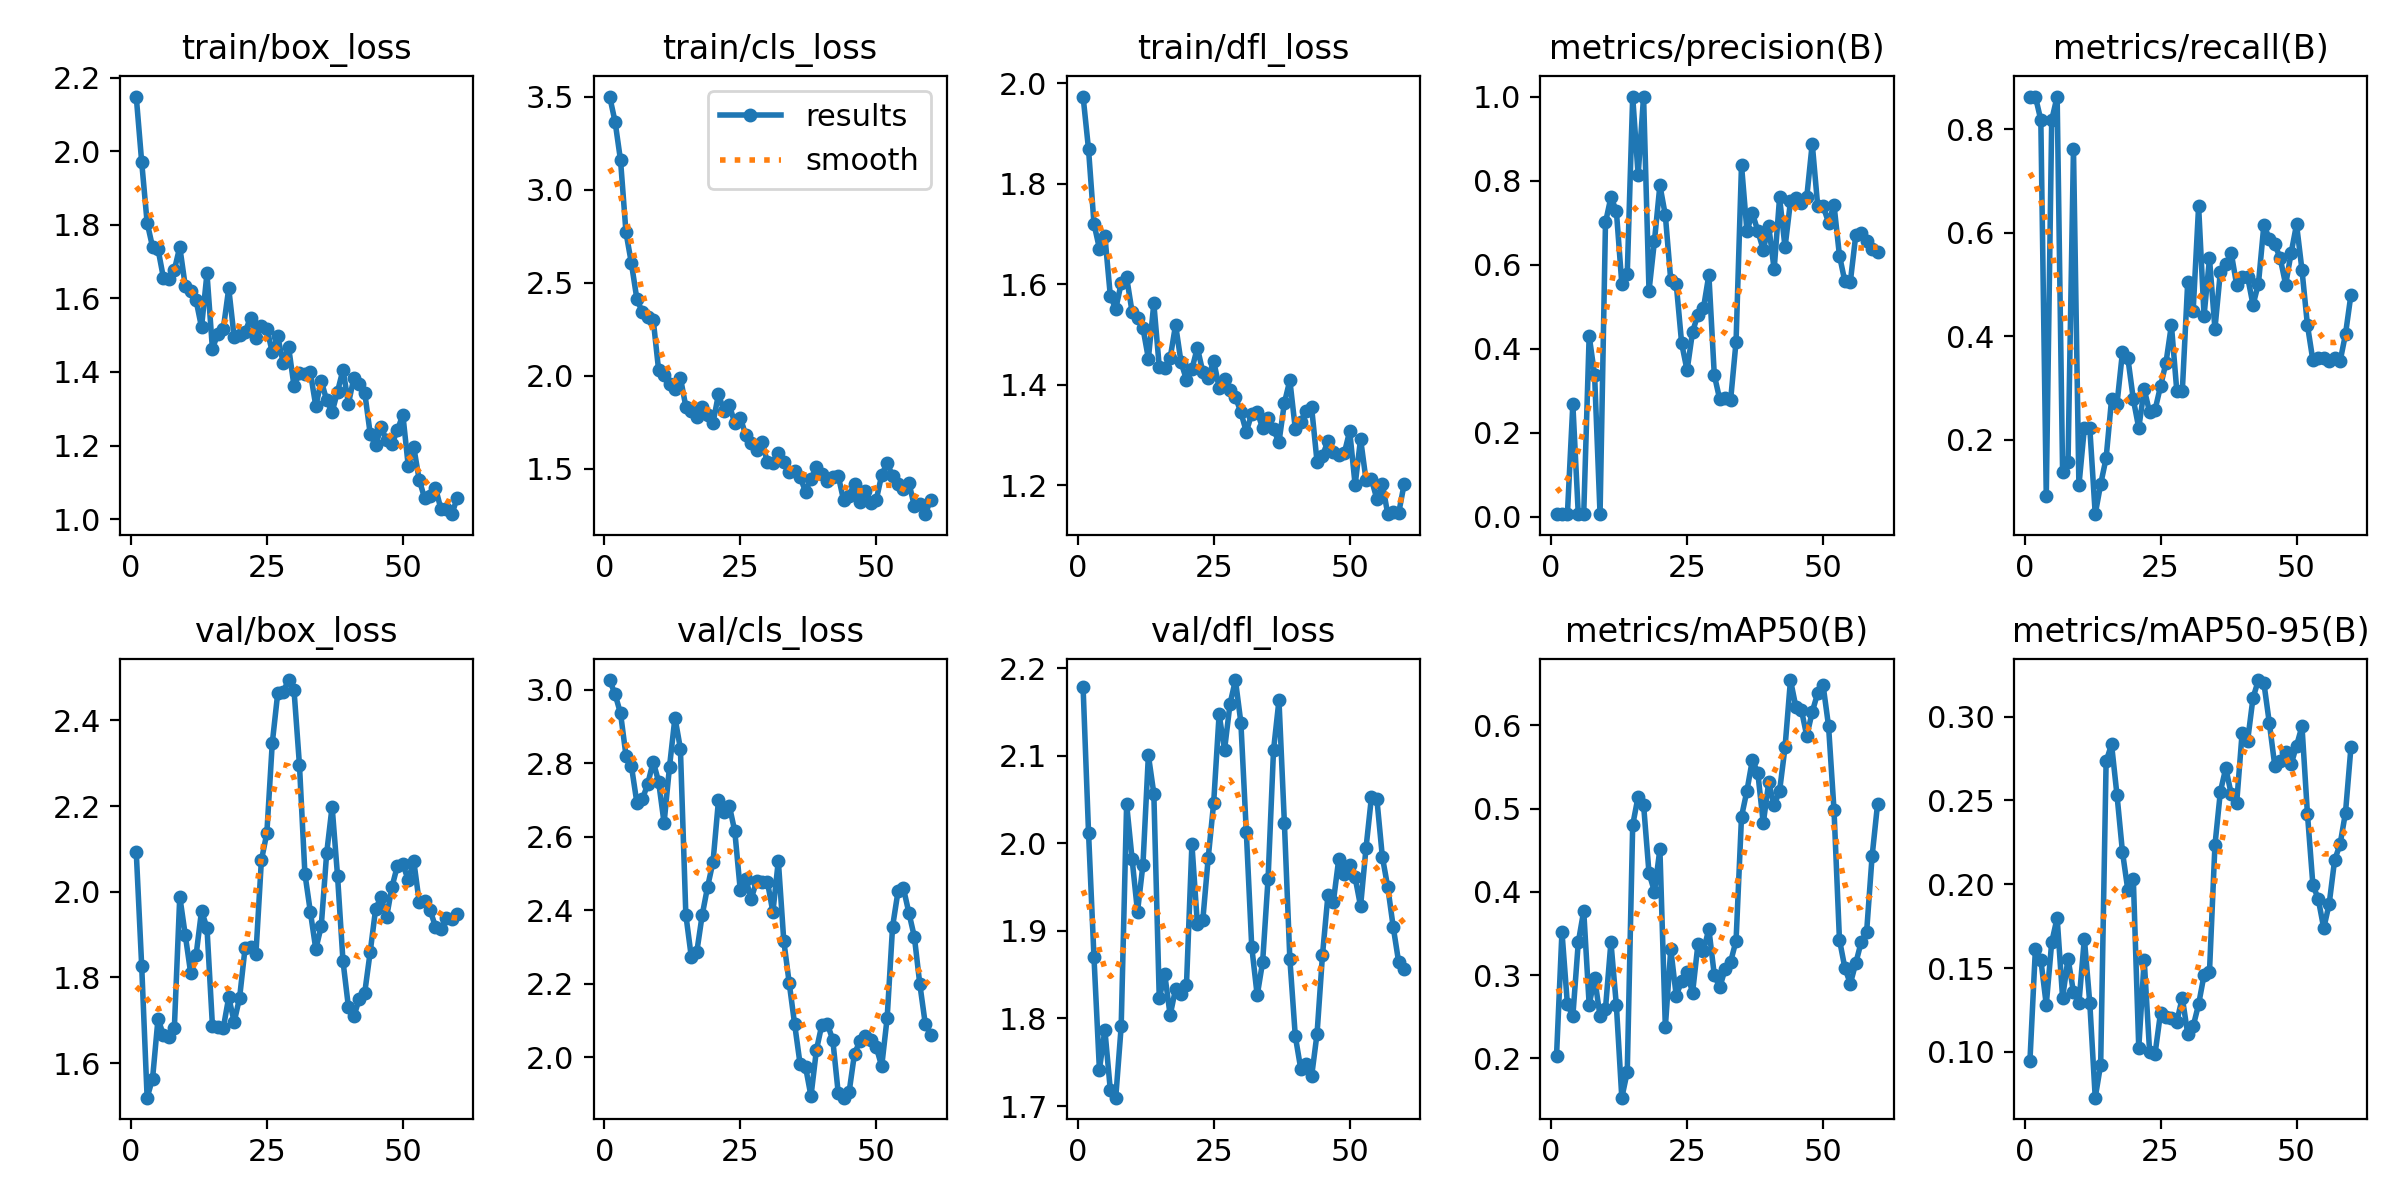

In [ ]:
from IPython.display import Image, display

display(Image('/content/drive/MyDrive/Projeto Fase 6/Resultados/exp_30/results.png'))
display(Image('/content/drive/MyDrive/Projeto Fase 6/Resultados/exp_60/results.png'))

FileNotFoundError: No such file or directory: '/content/drive/MyDrive/Projeto Fase 6/Resultados/exp_30/confusion_matrix.png'

FileNotFoundError: No such file or directory: '/content/drive/MyDrive/Projeto Fase 6/Resultados/exp_30/confusion_matrix.png'

<IPython.core.display.Image object>

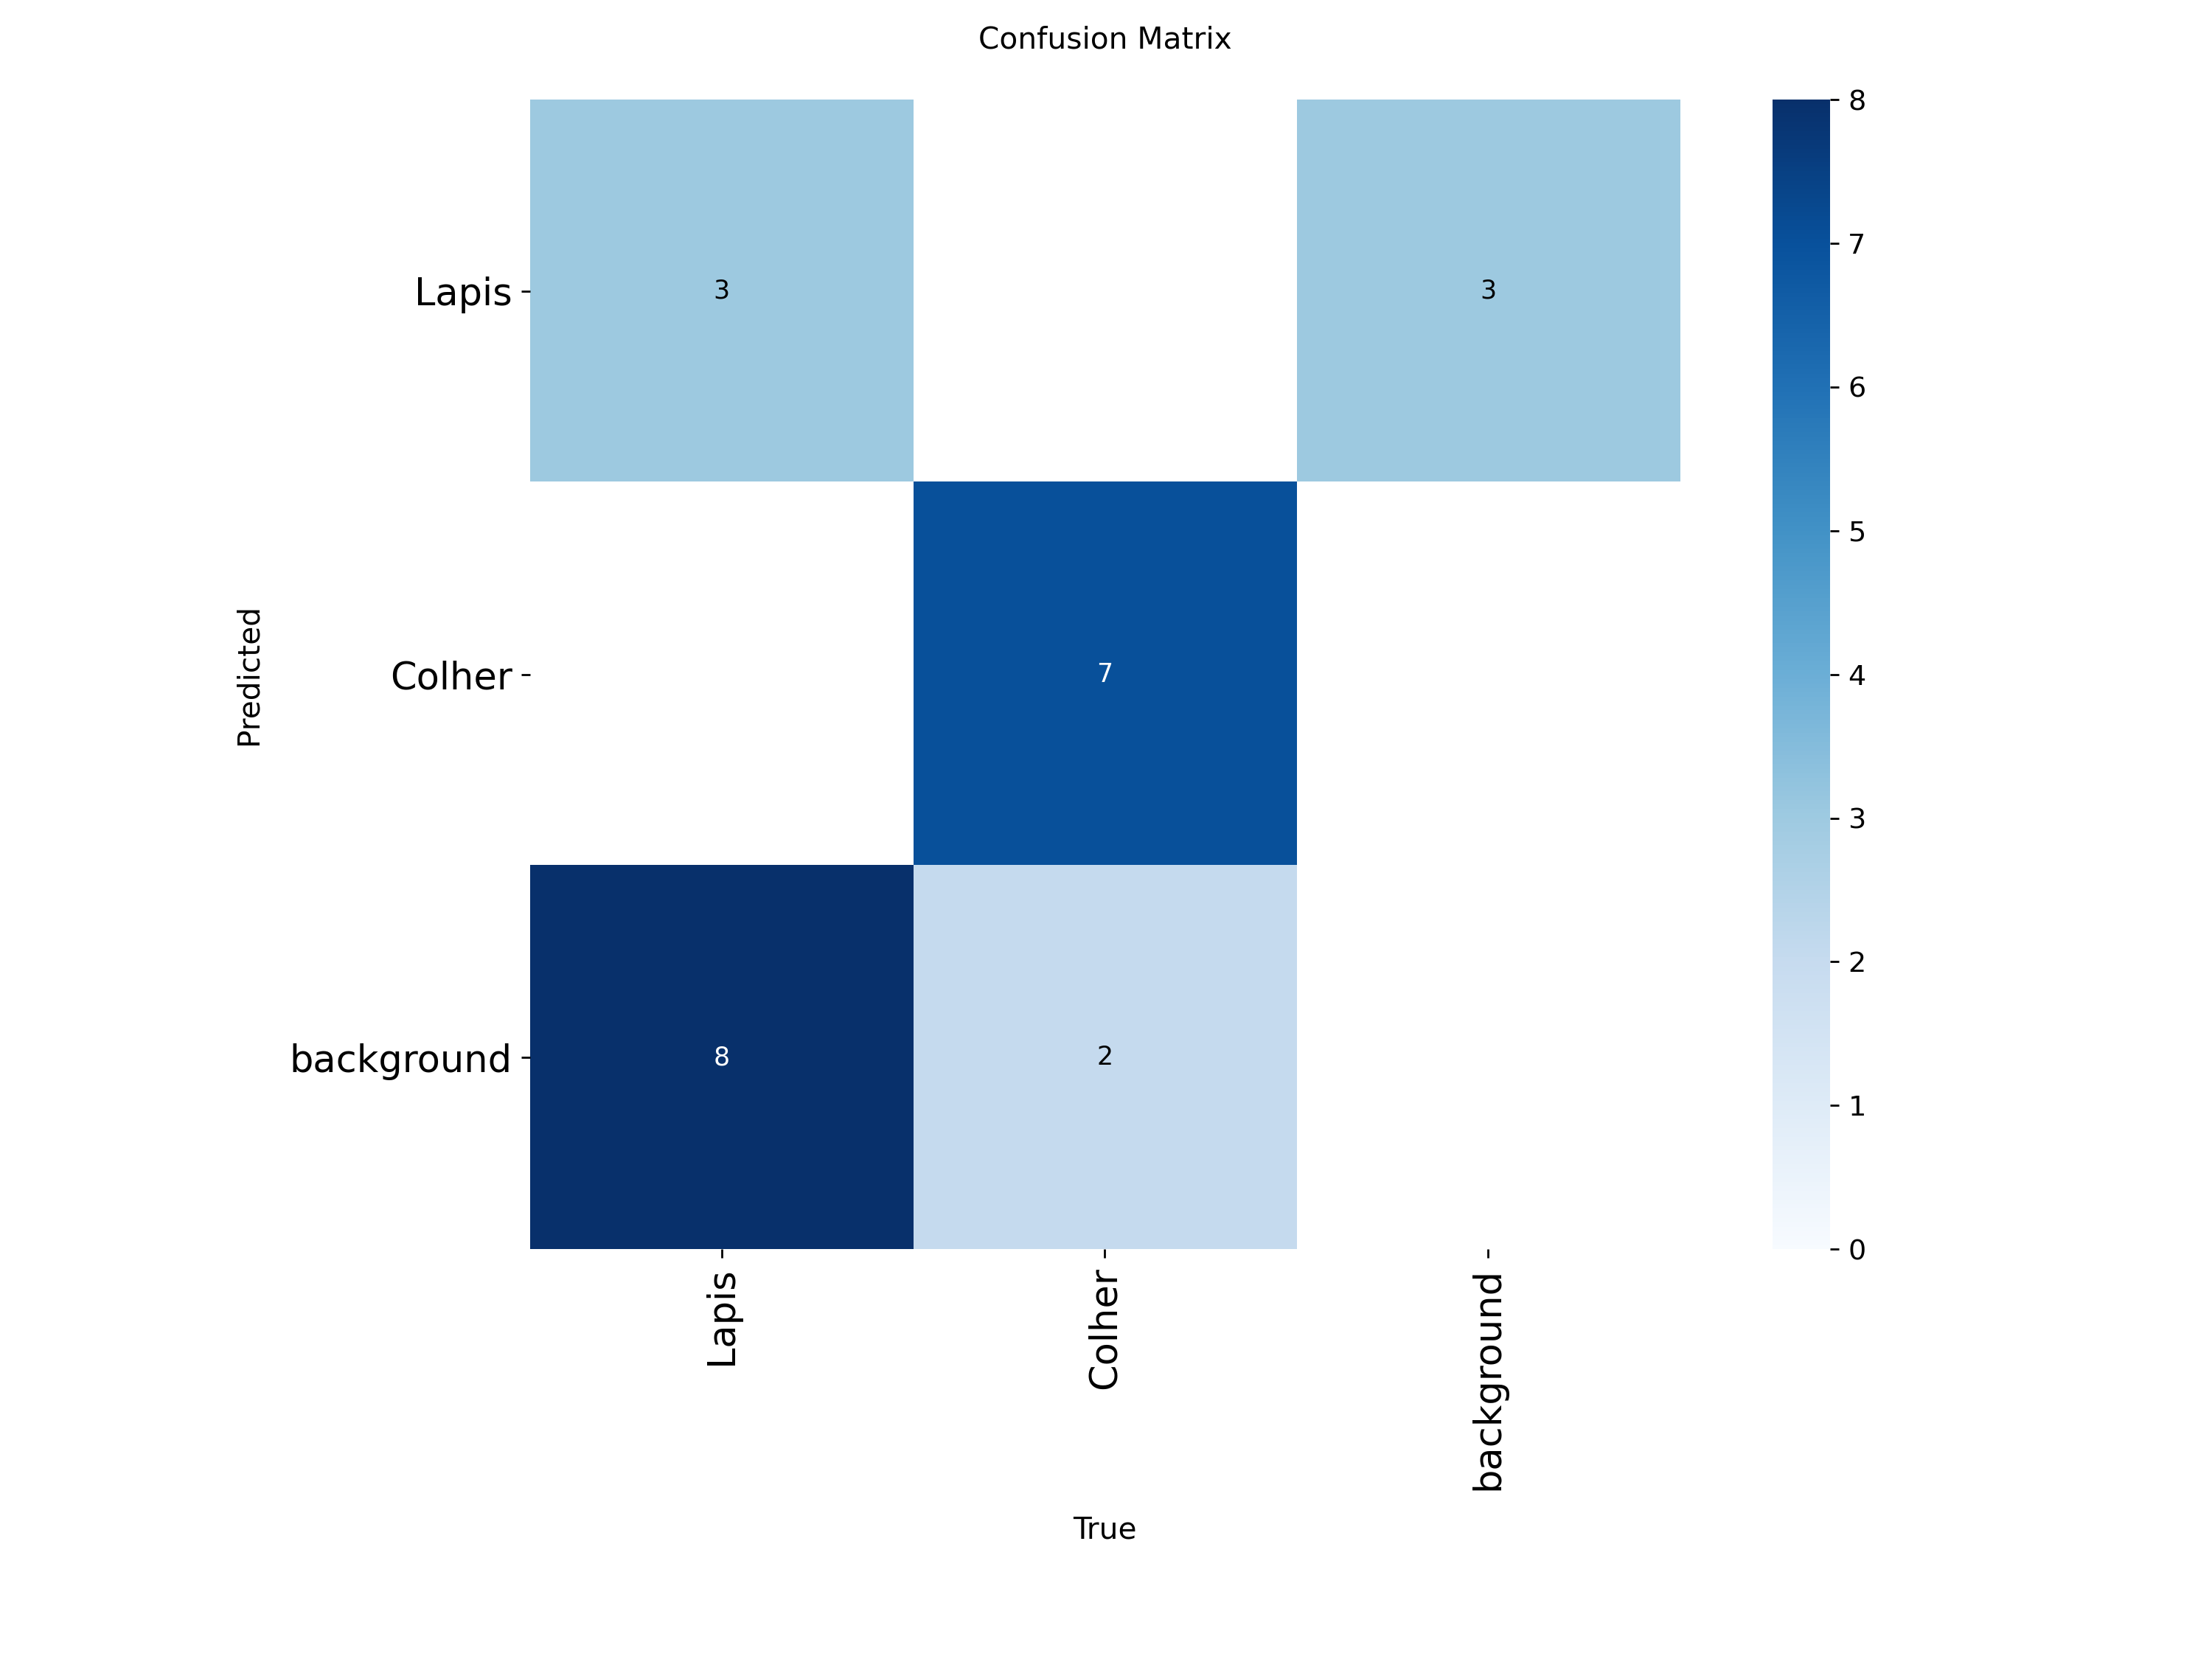

In [ ]:
display(Image('/content/drive/MyDrive/Projeto Fase 6/Resultados/exp_30/confusion_matrix.png'))
display(Image('/content/drive/MyDrive/Projeto Fase 6/Resultados/exp_60/confusion_matrix.png'))

In [ ]:
pred_dir = '/content/drive/MyDrive/Projeto Fase 6/Resultados/predicoes_teste'
print(os.listdir(pred_dir))

['Teste1.jpg', 'Teste2.jpg', 'Teste3.jpg', 'Teste4.jpg', 'Teste5.jpg', 'Teste7.jpg', 'Teste6.jpg', 'Teste8.jpg']


# **Yolo Tradicional**

Imagens encontradas: 8

Results saved to /content/drive/MyDrive/Projeto Fase 6/Resultados/yolo_tradicional
Results saved to /content/drive/MyDrive/Projeto Fase 6/Resultados/yolo_tradicional
Results saved to /content/drive/MyDrive/Projeto Fase 6/Resultados/yolo_tradicional
Results saved to /content/drive/MyDrive/Projeto Fase 6/Resultados/yolo_tradicional
Results saved to /content/drive/MyDrive/Projeto Fase 6/Resultados/yolo_tradicional
Results saved to /content/drive/MyDrive/Projeto Fase 6/Resultados/yolo_tradicional
Results saved to /content/drive/MyDrive/Projeto Fase 6/Resultados/yolo_tradicional
Results saved to /content/drive/MyDrive/Projeto Fase 6/Resultados/yolo_tradicional
Tempo médio de inferência YOLO padrão: 0.2401s
Total de imagens testadas: 8

Imagens processadas: 8


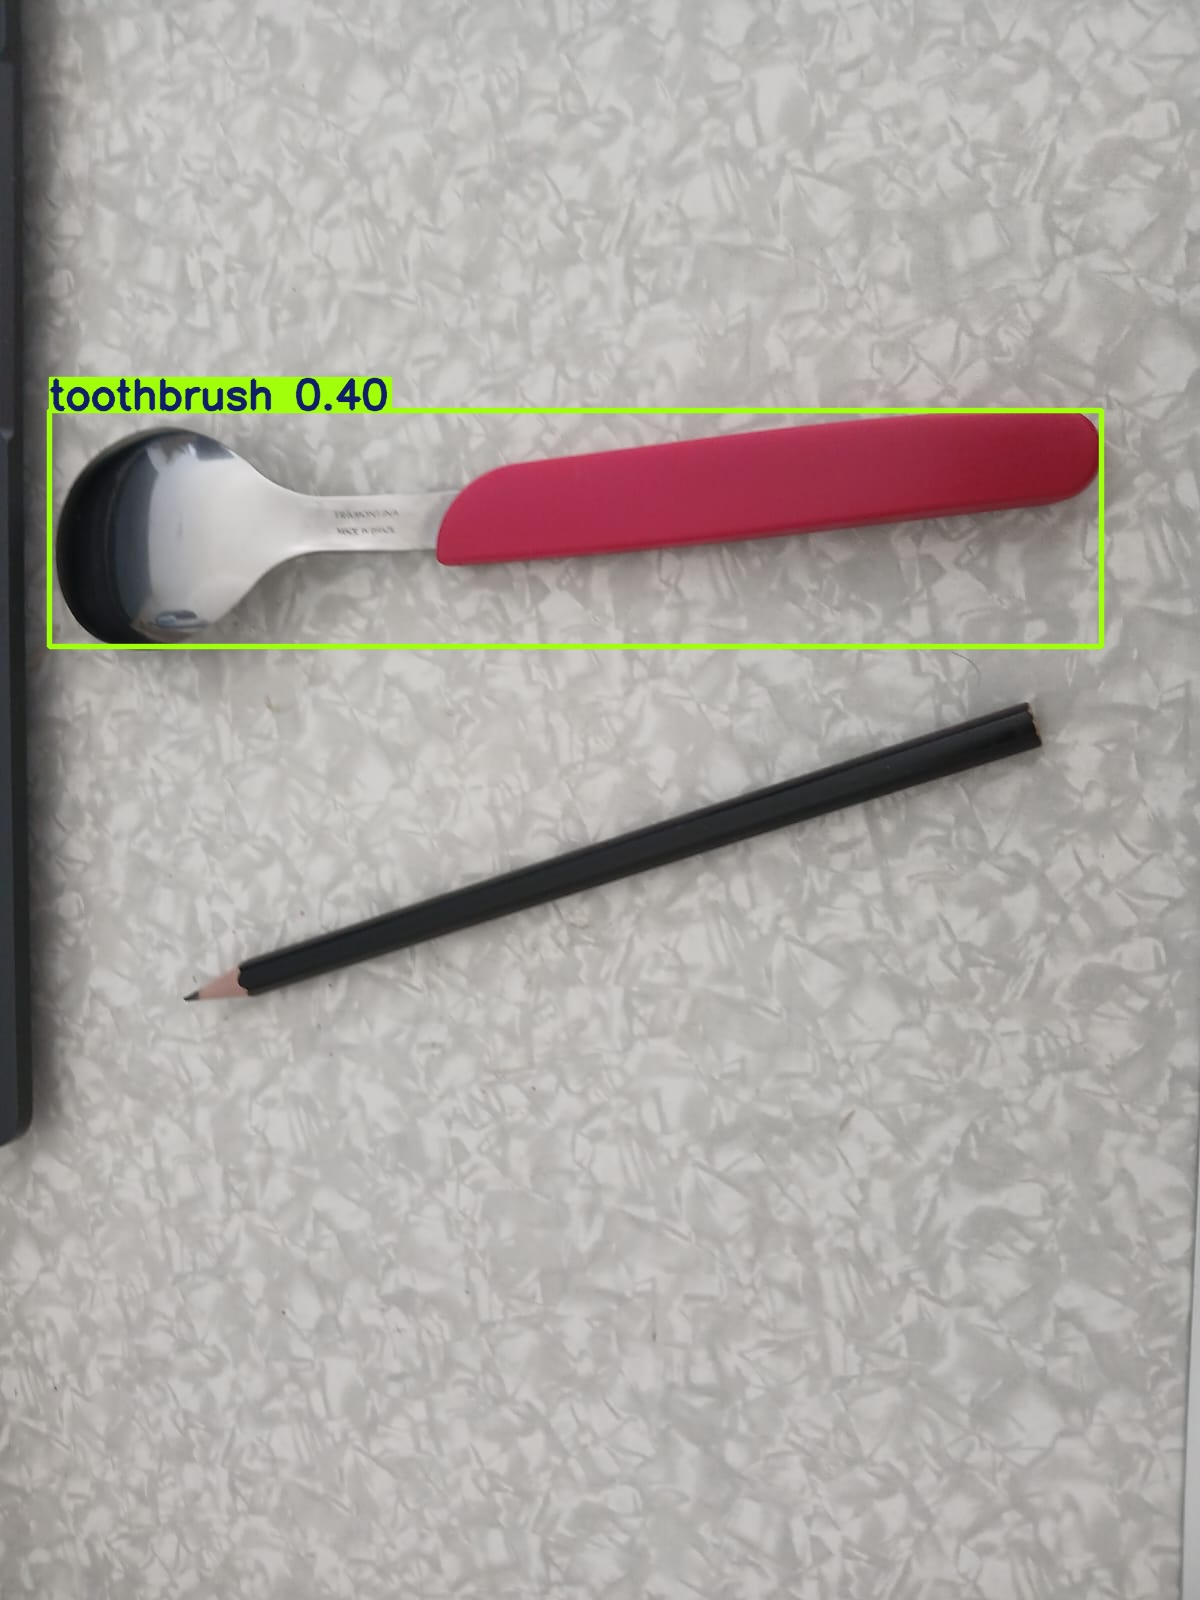

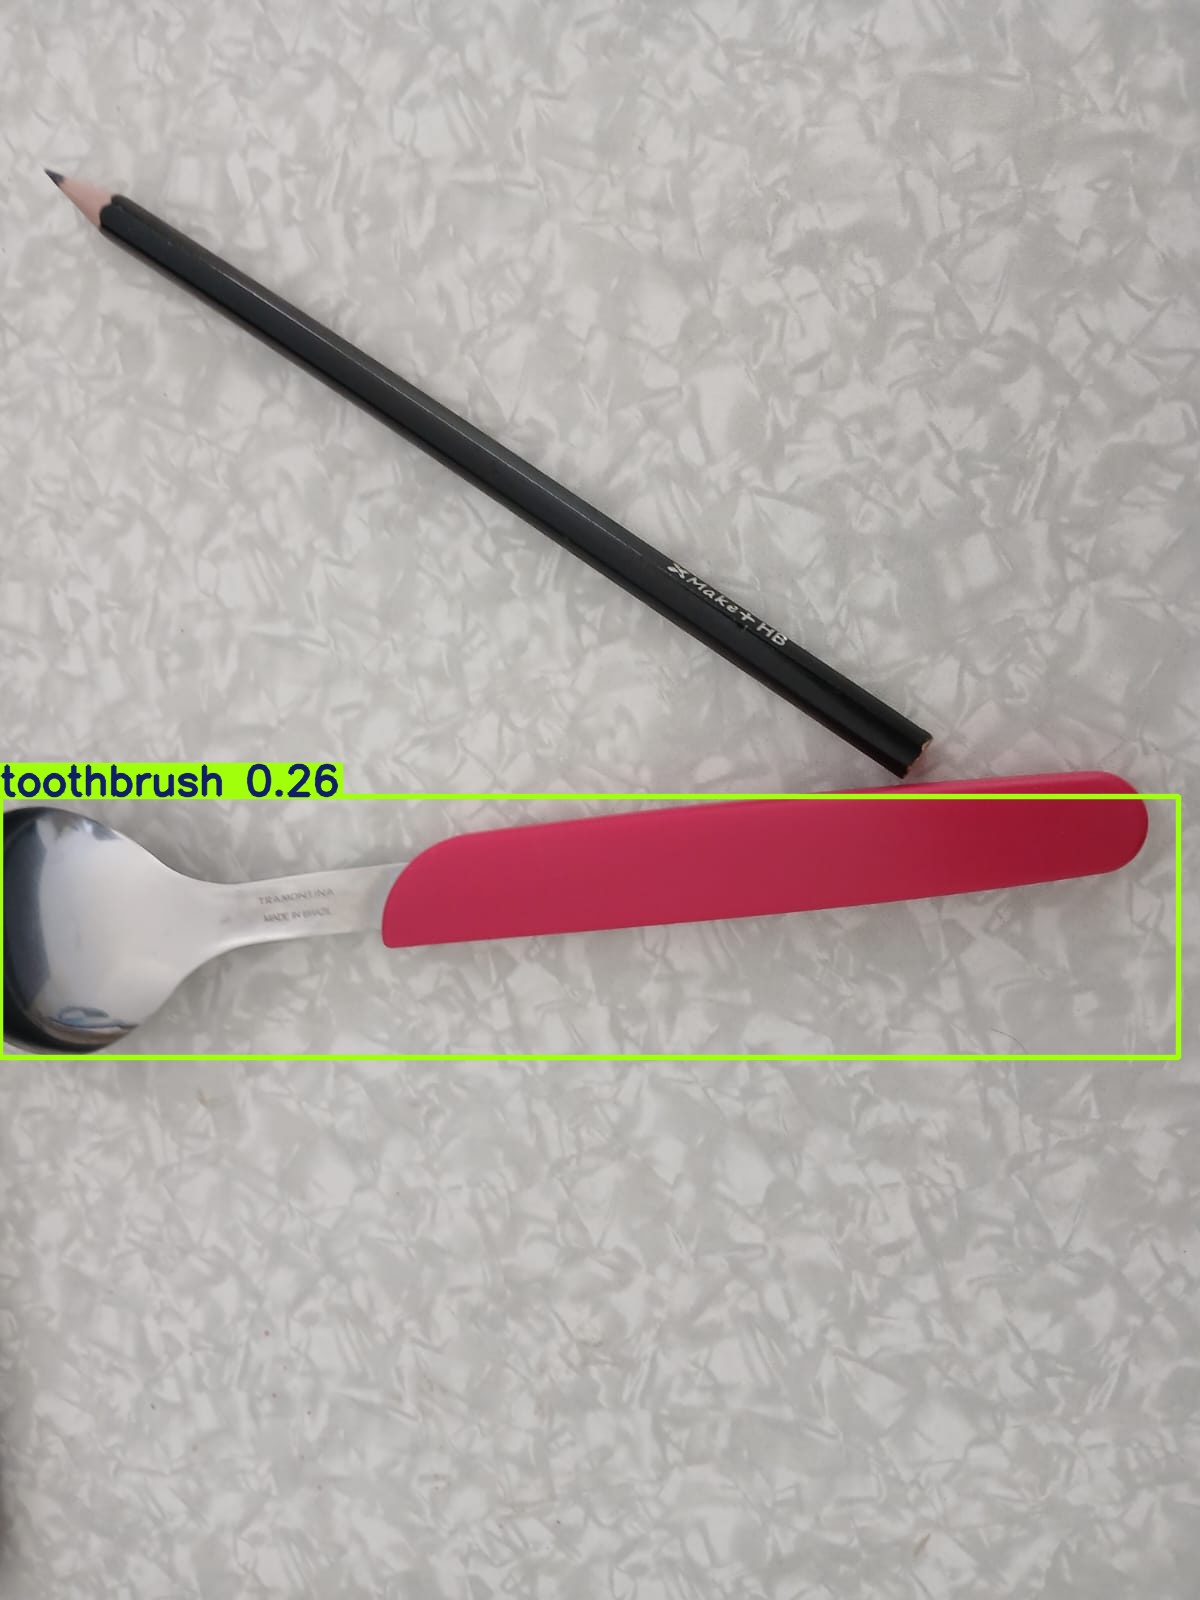

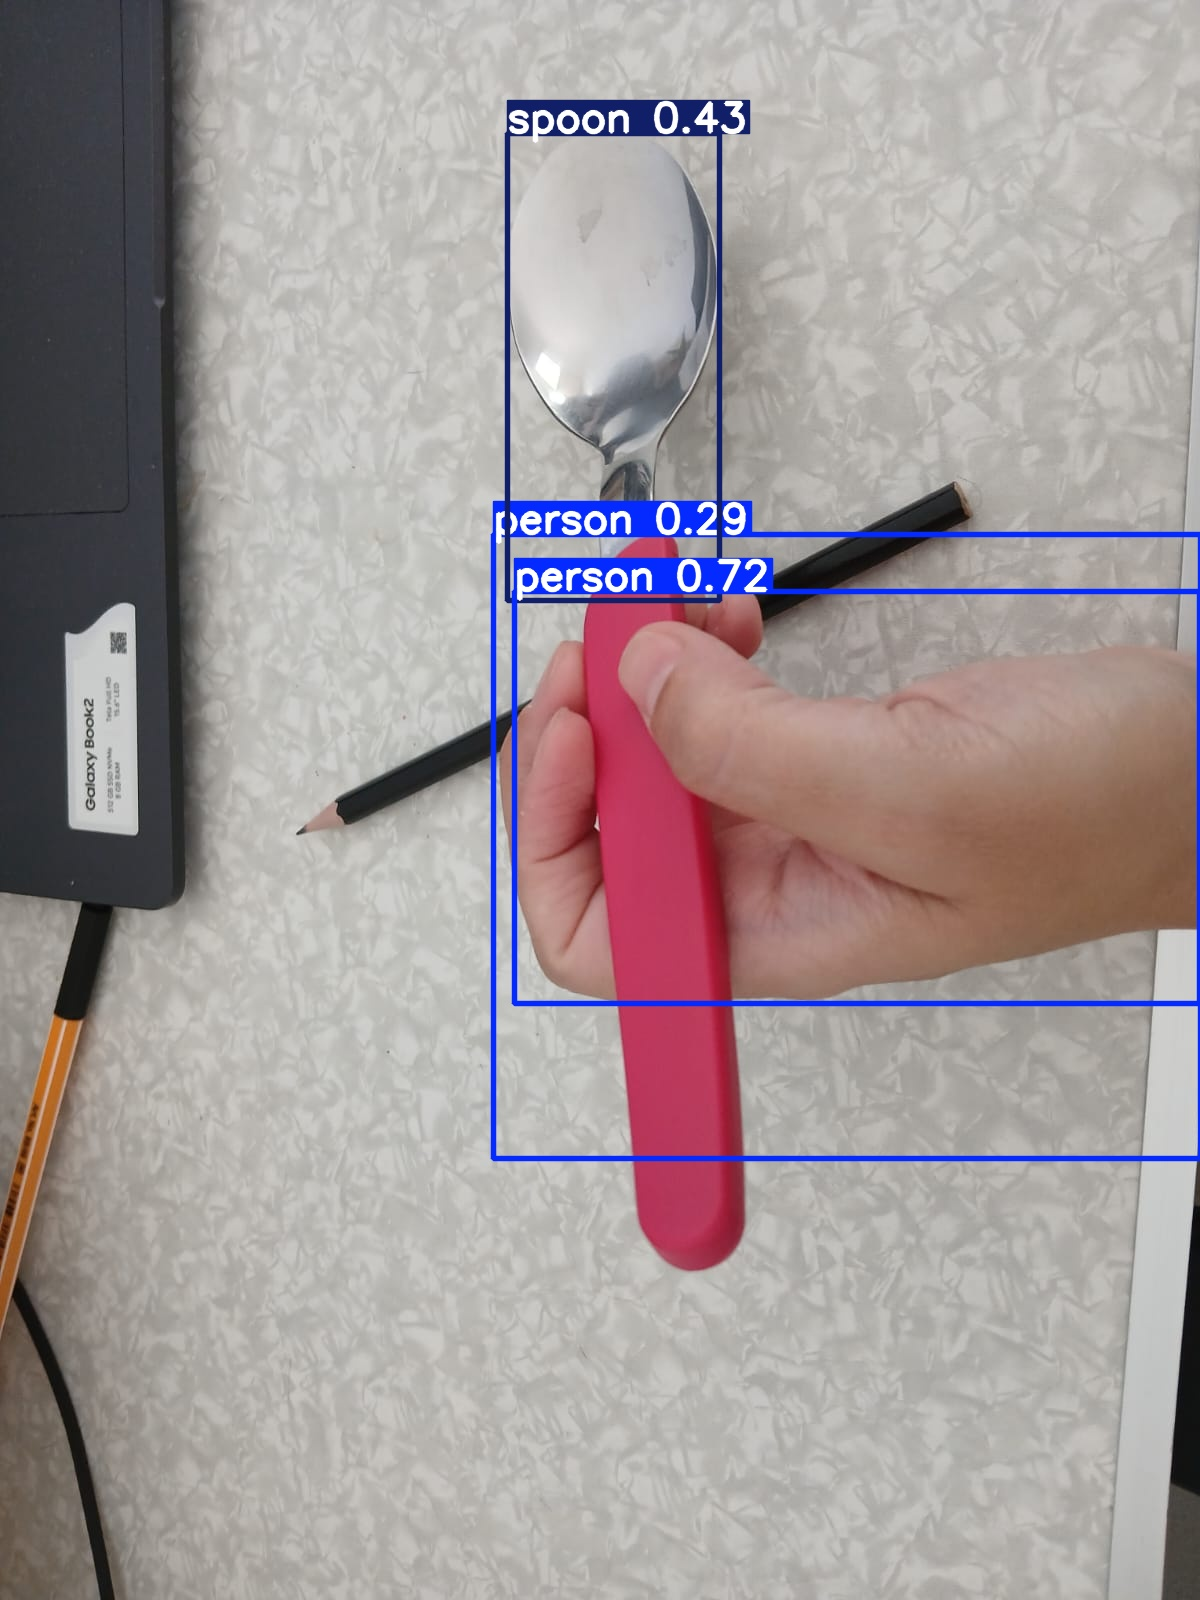

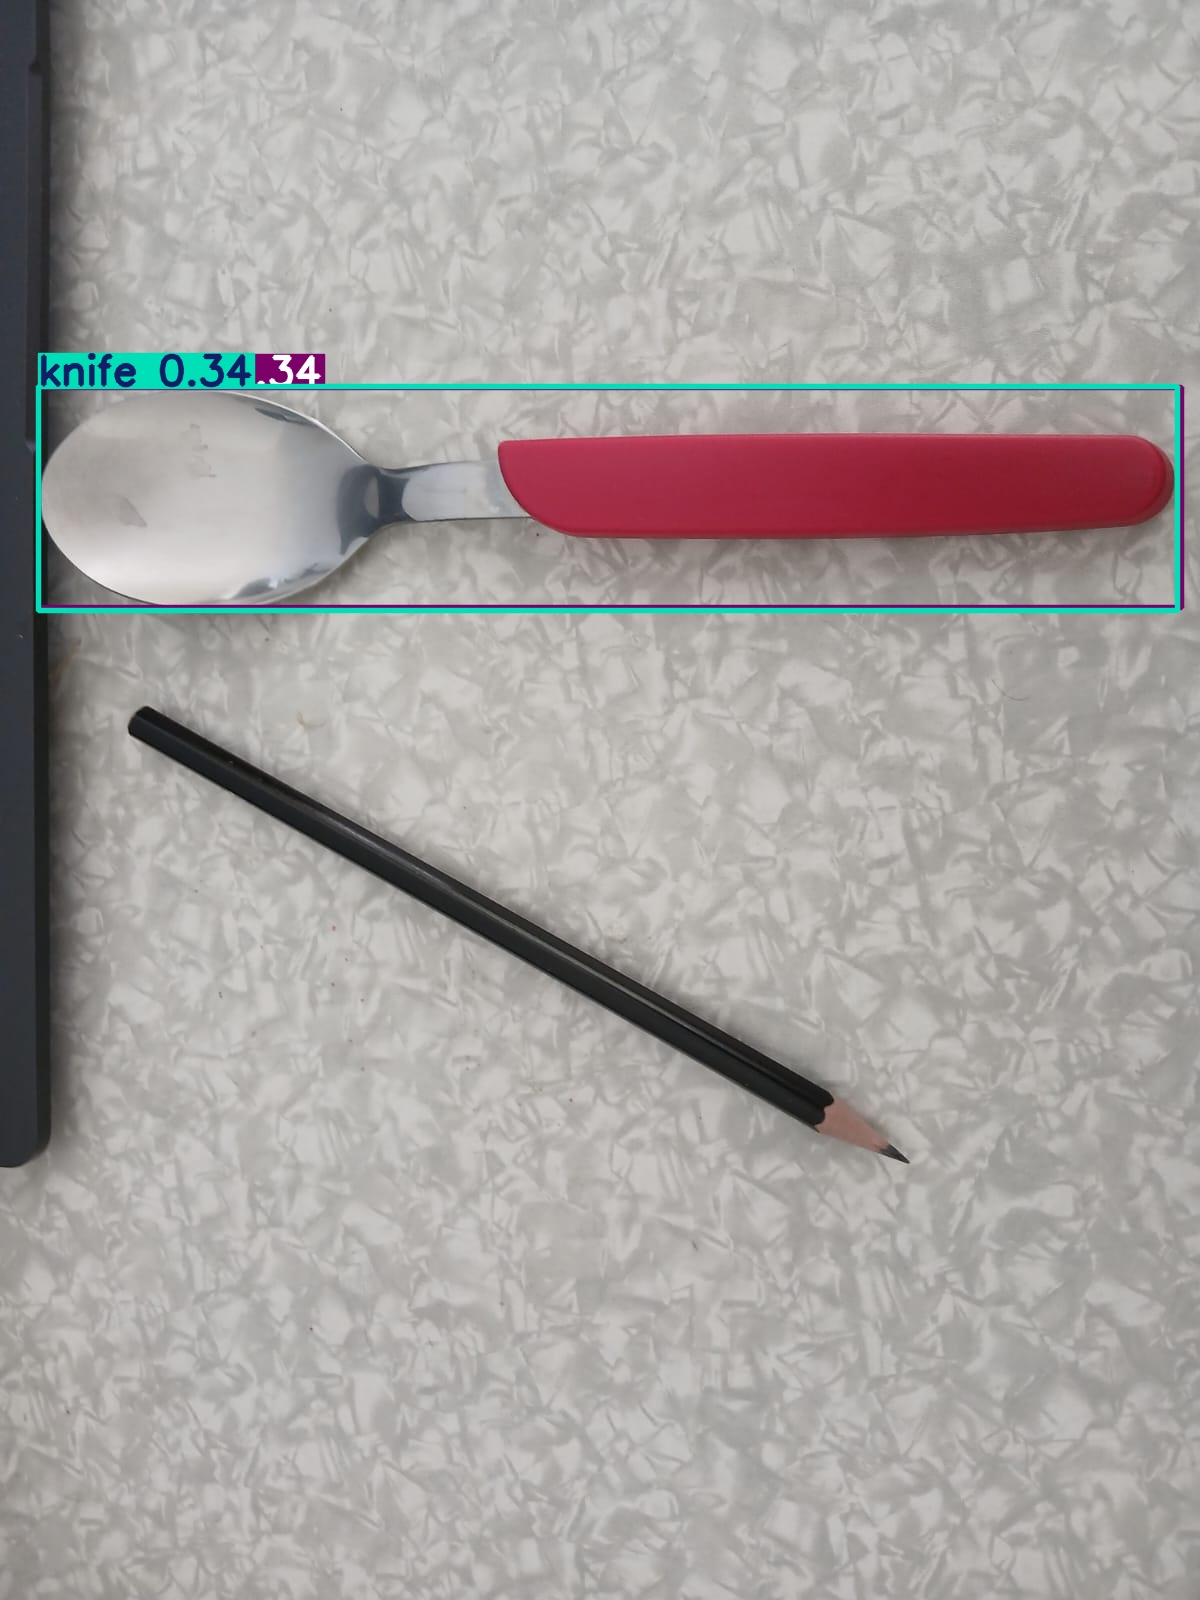

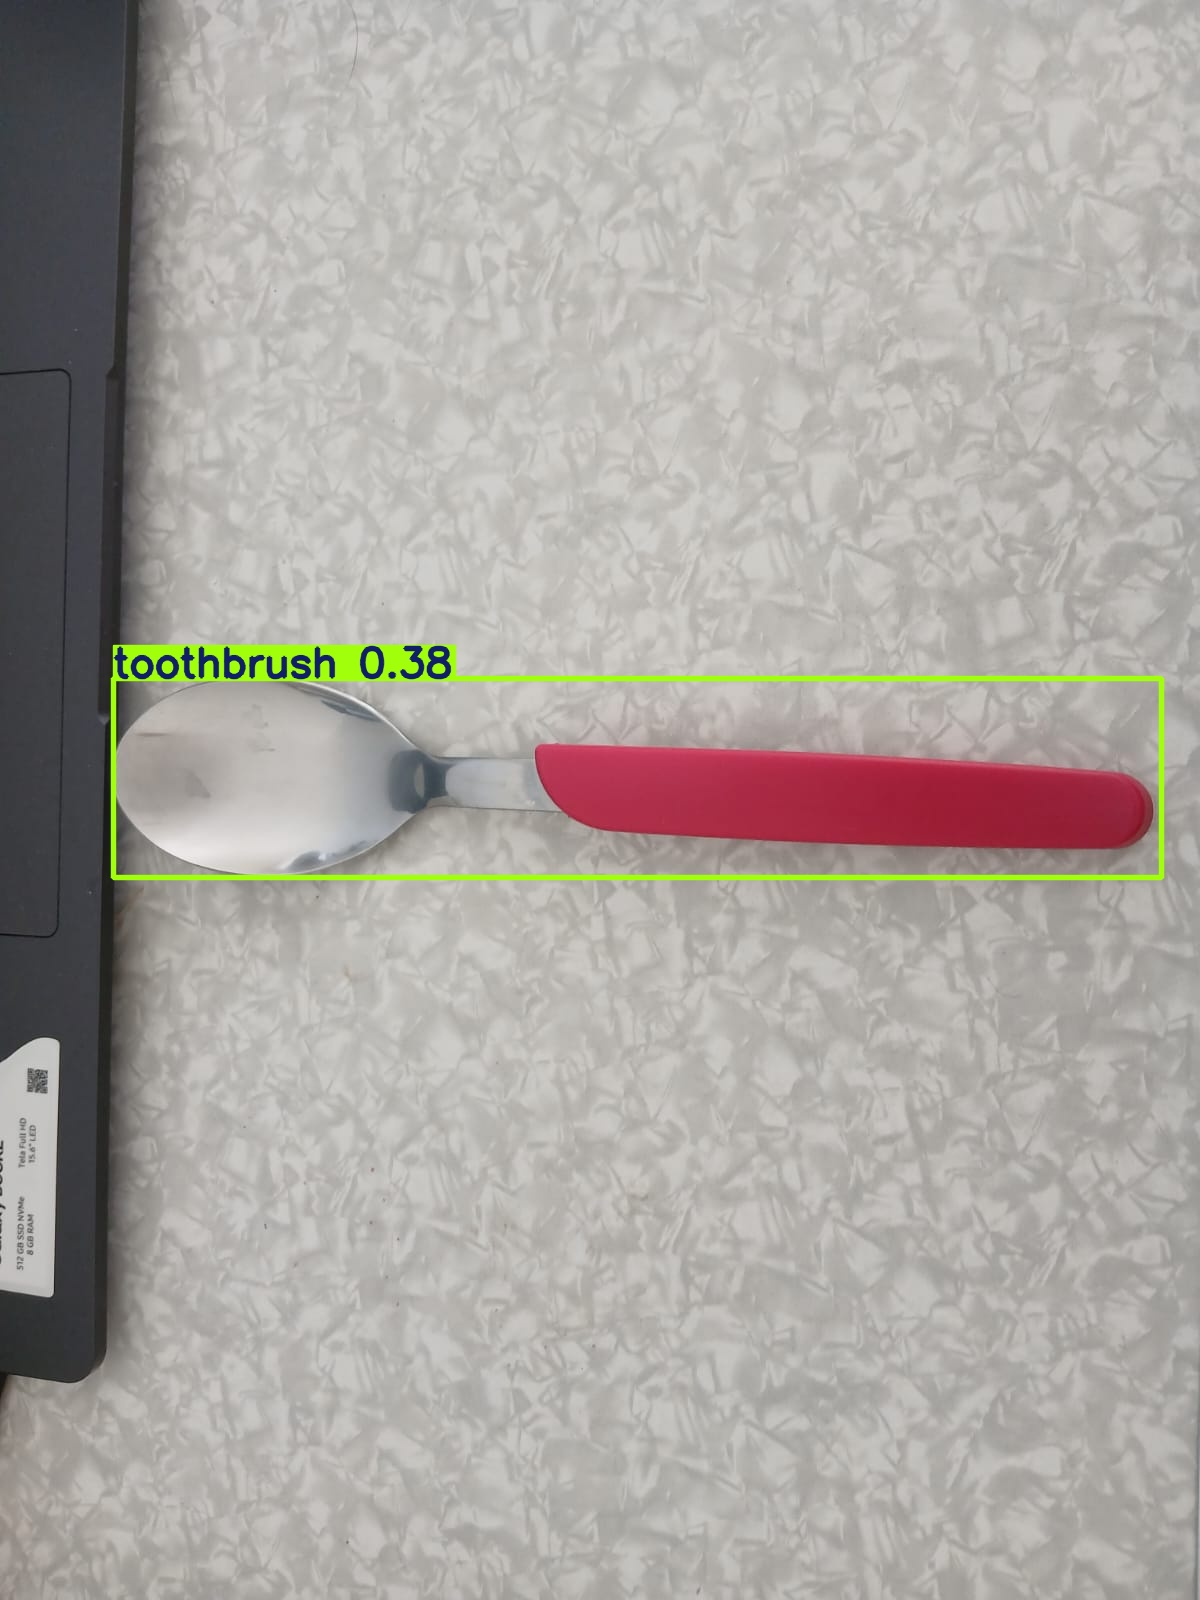

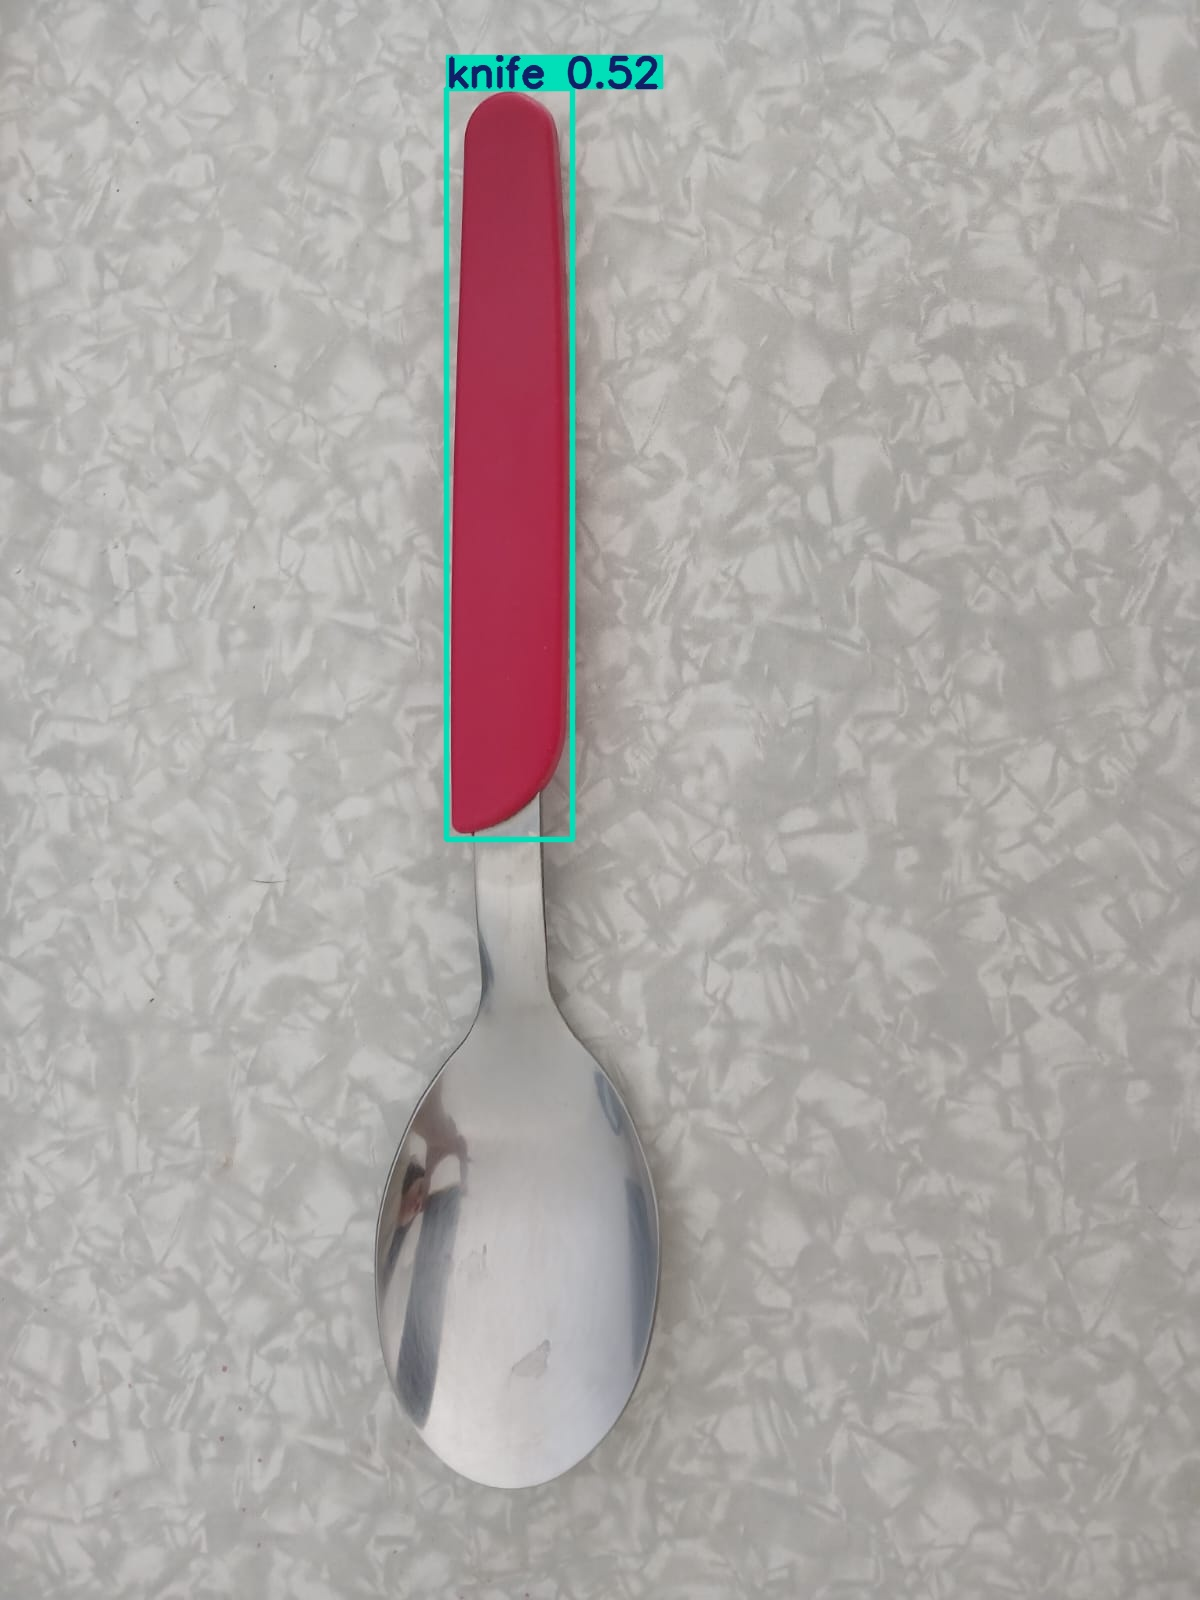

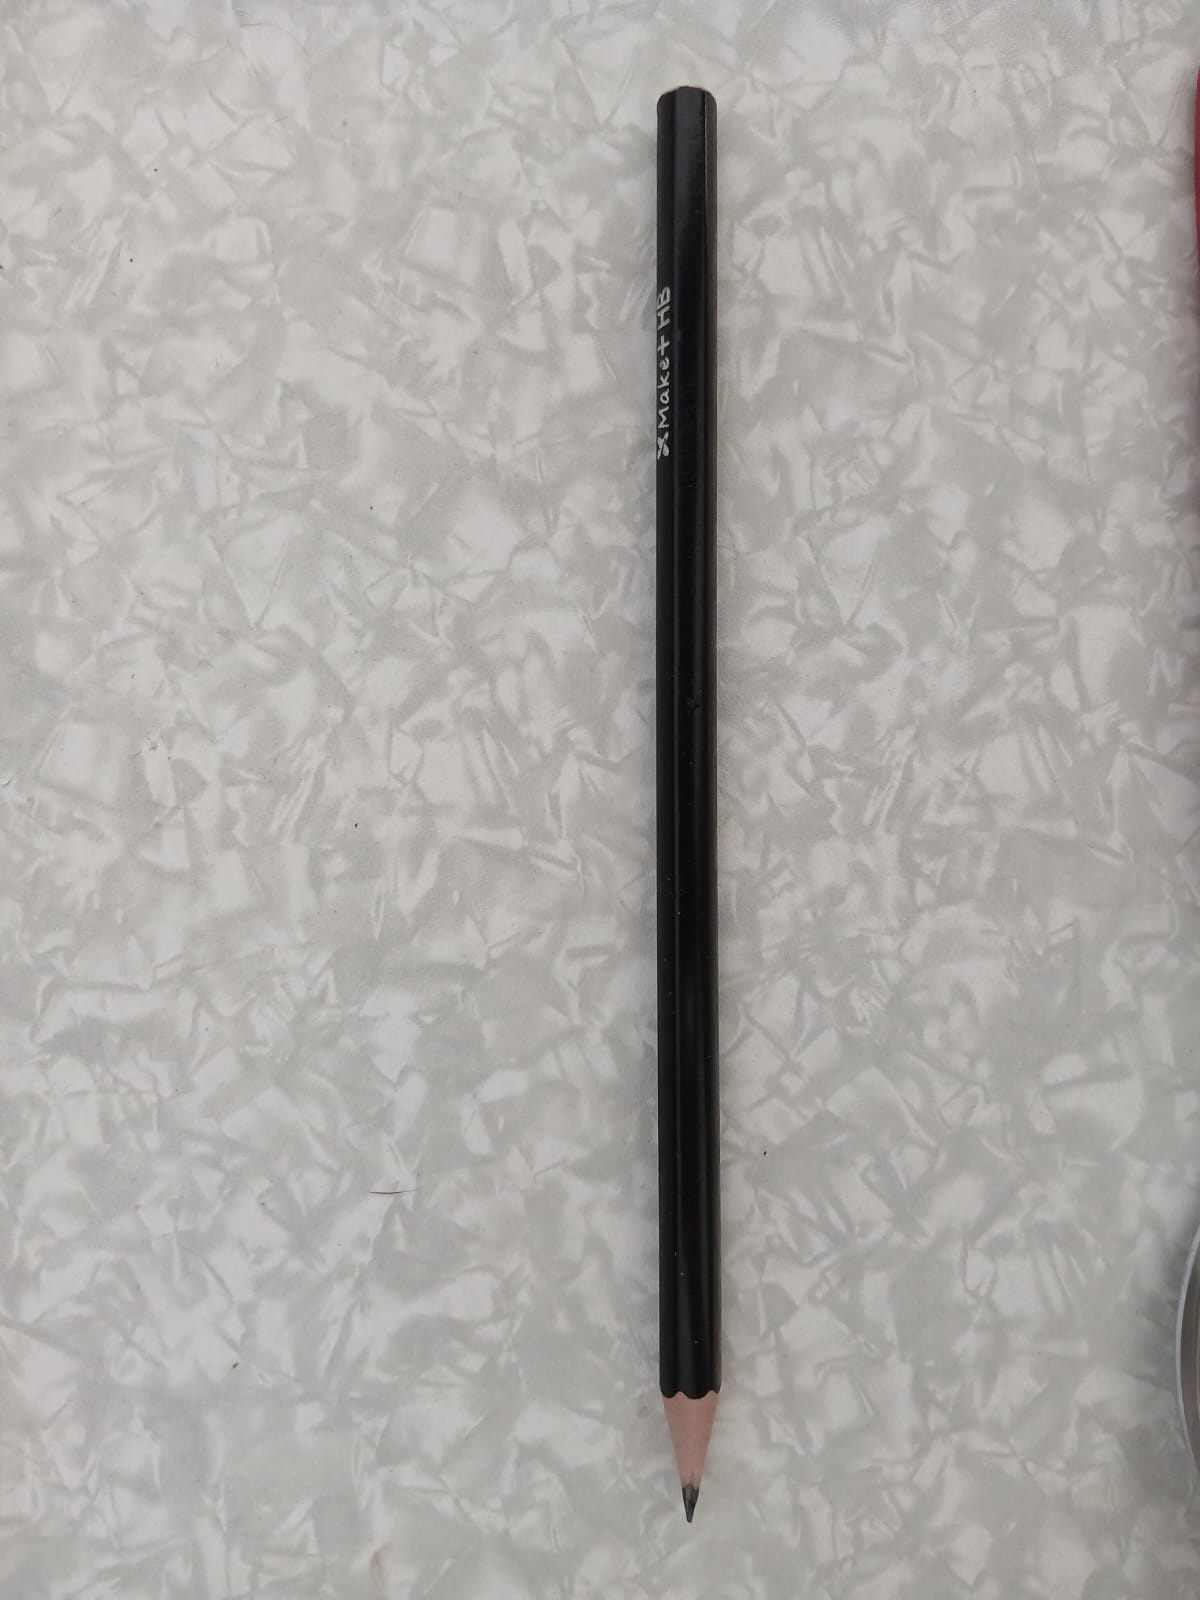

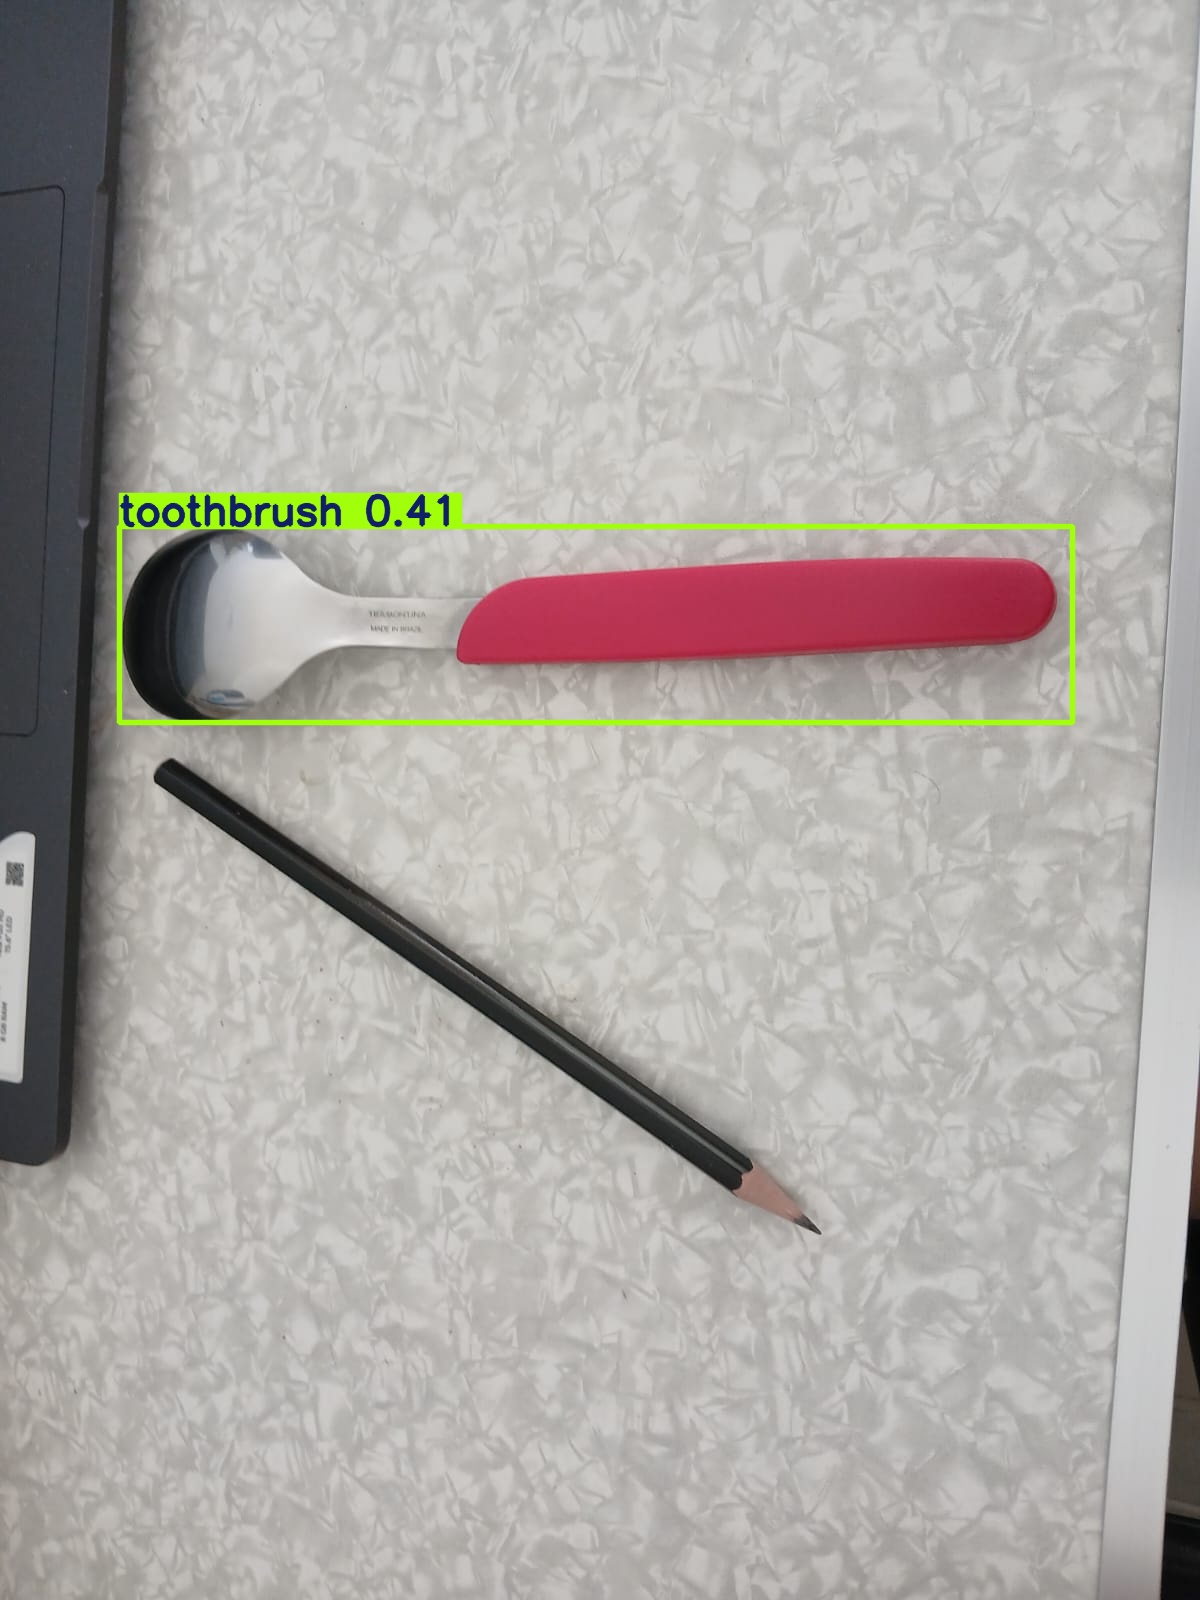

In [6]:
import time
import glob
from IPython.display import Image, display

!pip install ultralytics -q
from ultralytics import YOLO

modelo_tradicional = YOLO('yolov8n.pt')

path_teste = '/content/drive/MyDrive/Projeto Fase 6/Teste/images'

imagens_teste = sorted(glob.glob(path_teste + '/*.jpg') +
                       glob.glob(path_teste + '/*.jpeg') +
                       glob.glob(path_teste + '/*.png'))

print(f"Imagens encontradas: {len(imagens_teste)}\n")

tempos = []

for img_path in imagens_teste:
    start = time.time()
    modelo_tradicional.predict(
        source=img_path,
        save=True,
        project='/content/drive/MyDrive/Projeto Fase 6/Resultados',
        name='yolo_tradicional',
        exist_ok=True,
        verbose=False
    )
    end = time.time()
    tempos.append(end - start)

print(f"Tempo médio de inferência YOLO padrão: {sum(tempos)/len(tempos):.4f}s")
print(f"Total de imagens testadas: {len(tempos)}")

imagens_resultado = glob.glob('/content/drive/MyDrive/Projeto Fase 6/Resultados/yolo_tradicional/*.jpg')

print(f"\nImagens processadas: {len(imagens_resultado)}")
for img_path in sorted(imagens_resultado):
    display(Image(filename=img_path, width=400))

## **CNN Preparação**

In [2]:
import os

pastas = [
    '/content/drive/MyDrive/Projeto Fase 6/Treino_CNN/Lapis',
    '/content/drive/MyDrive/Projeto Fase 6/Treino_CNN/Colher',
    '/content/drive/MyDrive/Projeto Fase 6/Teste_CNN'
]

for pasta in pastas:
    if os.path.exists(pasta):
        arquivos = os.listdir(pasta)
        for f in arquivos:
            if not f.lower().endswith(('.png', '.jpg', '.jpeg', '.webp')):
                caminho_completo = os.path.join(pasta, f)
                try:
                    print(f"Removendo arquivo inválido de {pasta}: {f}")
                    os.remove(caminho_completo)
                except:
                    pass
    else:
        print(f"Atenção: A pasta {pasta} não foi encontrada.")

In [3]:
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models

path_cnn ='/content/drive/MyDrive/Projeto Fase 6/Treino_CNN'

train_ds = tf.keras.utils.image_dataset_from_directory(
  path_cnn,
  validation_split=0.2,
  subset="training",
  seed=123,
  image_size=(128, 128),
  batch_size=8)

val_ds = tf.keras.utils.image_dataset_from_directory(
  path_cnn,
  validation_split=0.2,
  subset="validation",
  seed=123,
  image_size=(128, 128),
  batch_size=8)

class_names = train_ds.class_names
print(f"Classes identificadas: {class_names}")

Found 80 files belonging to 2 classes.
Using 64 files for training.
Found 80 files belonging to 2 classes.
Using 16 files for validation.
Classes identificadas: ['Colher', 'Lapis']


# **CNN**

In [4]:

model_cnn = models.Sequential([
  layers.Input(shape=(128, 128, 3)),

  layers.RandomFlip("horizontal"),
  layers.RandomRotation(0.1),
  layers.Rescaling(1./255),

  layers.Conv2D(32, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),

  layers.Conv2D(64, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),

  layers.Conv2D(128, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),

  layers.Flatten(),
  layers.Dense(128, activation='relu'),
  layers.Dropout(0.2),
  layers.Dense(len(class_names), activation='softmax')
])

model_cnn.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(),
              metrics=['accuracy'])

history = model_cnn.fit(
  train_ds,
  validation_data=val_ds,
  epochs=20
)

Epoch 1/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 21s 2s/step - accuracy: 0.4688 - loss: 0.8709 - val_accuracy: 0.5625 - val_loss: 0.6917
Epoch 2/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 81ms/step - accuracy: 0.5625 - loss: 0.6943 - val_accuracy: 0.3750 - val_loss: 0.7152
Epoch 3/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 77ms/step - accuracy: 0.5312 - loss: 0.6931 - val_accuracy: 0.3750 - val_loss: 0.6991
Epoch 4/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 78ms/step - accuracy: 0.5312 - loss: 0.6925 - val_accuracy: 0.3750 - val_loss: 0.6931
Epoch 5/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 79ms/step - accuracy: 0.6406 - loss: 0.6833 - val_accuracy: 0.3750 - val_loss: 0.7354
Epoch 6/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 71ms/step - accuracy: 0.5625 - loss: 0.6780 - val_accuracy: 0.6250 - val_loss: 0.6286
Epoch 7/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 81ms/step - accuracy: 0.5938 - loss: 0.6688 - val_accuracy: 0.6250 - val_loss: 0.6744
Epoch 8/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 80ms/step - accuracy: 0.5938 - loss: 0.6523 - val_accuracy: 0.6875 - val_loss: 0.6881
E

In [6]:
import time
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing import image


path_teste = '/content/drive/MyDrive/Projeto Fase 6/Teste_CNN'
arquivos_teste = sorted([f for f in os.listdir(path_teste) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])

print(f"🚀 Iniciando inferência em {len(arquivos_teste)} imagens...\n")

total_time = 0
acertos = 0

for img_name in arquivos_teste:
    img_path = os.path.join(path_teste, img_name)

    img = image.load_img(img_path, target_size=(128, 128))
    img_array = image.img_to_array(img)
    img_array = tf.expand_dims(img_array, 0)

    start_time = time.time()
    predictions = model_cnn.predict(img_array, verbose=0)
    end_time = time.time()

    inference_time = end_time - start_time
    total_time += inference_time

    score = tf.nn.softmax(predictions[0])
    classe_predita = class_names[np.argmax(score)]
    confianca = 100 * np.max(score)

    if classe_predita.lower() in img_name.lower():
        acertos += 1
        status = "✅ ACERTO"
    else:
        status = "❌ ERRO"
    # ---------------------------------------------------

    print(f"🖼️ Arquivo: {img_name}")
    print(f"🔎 Resultado: {classe_predita} ({confianca:.2f}%) | {status}")
    print(f"⏱️ Tempo: {inference_time:.4f}s")
    print("-" * 45)

print(f"\n📊 RESULTADOS FINAIS:")
print(f"✅ Acurácia no teste: {acertos}/{len(arquivos_teste)} ({acertos/len(arquivos_teste):.2%})")
print(f"⏱️ Tempo Médio de Inferência: {total_time/len(arquivos_teste):.4f} segundos")

🚀 Iniciando inferência em 8 imagens...

🖼️ Arquivo: teste_colher_01.jpg
🔎 Resultado: Lapis (72.79%) | ❌ ERRO
⏱️ Tempo: 0.0869s
---------------------------------------------
🖼️ Arquivo: teste_colher_02.jpg
🔎 Resultado: Colher (56.44%) | ✅ ACERTO
⏱️ Tempo: 0.0703s
---------------------------------------------
🖼️ Arquivo: teste_colher_03.jpg
🔎 Resultado: Colher (55.08%) | ✅ ACERTO
⏱️ Tempo: 0.0686s
---------------------------------------------
🖼️ Arquivo: teste_colher_04.jpg
🔎 Resultado: Colher (62.90%) | ✅ ACERTO
⏱️ Tempo: 0.0691s
---------------------------------------------
🖼️ Arquivo: teste_lapis_01.jpg
🔎 Resultado: Lapis (72.81%) | ✅ ACERTO
⏱️ Tempo: 0.0742s
---------------------------------------------
🖼️ Arquivo: teste_lapis_02.jpg
🔎 Resultado: Lapis (59.62%) | ✅ ACERTO
⏱️ Tempo: 0.0698s
---------------------------------------------
🖼️ Arquivo: teste_lapis_03.jpg
🔎 Resultado: Lapis (73.10%) | ✅ ACERTO
⏱️ Tempo: 0.0682s
---------------------------------------------
🖼️ Arquivo: teste

## **Resultados**

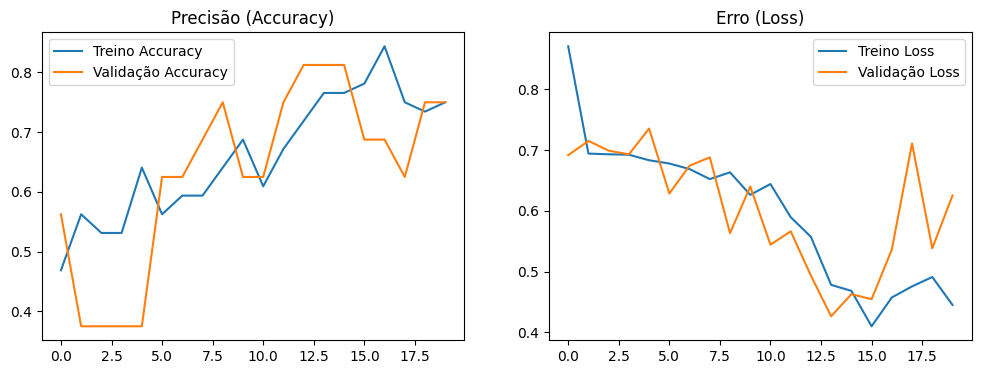

In [8]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Treino Accuracy')
plt.plot(epochs_range, val_acc, label='Validação Accuracy')
plt.title('Precisão (Accuracy)')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Treino Loss')
plt.plot(epochs_range, val_loss, label='Validação Loss')
plt.title('Erro (Loss)')
plt.legend()
plt.show()